# Model 5 — Body Damage Probability Estimator (Logistic Regression)

## Research Question
Based on what is visible in a car listing — its age, mileage, and seller type — what is the probability that this car has sustained body damage?

## Introduction
This notebook uses **Logistic Regression** to estimate the probability that a car has body damage, based on listing-visible features only.

**Rules for this notebook:**
- Uses **unscaled data** (`proceed_dataset_without_scaling.csv`)
- You **must use `LogisticRegression`** — and output must be probability via `predict_proba()`
- You **must create the `is_damaged` binary column** before training (see Feature Engineering)
- You **must drop all Team 3 damage columns** from features to avoid data leakage (list provided in Feature Engineering)
- You **may choose different features**, add features, and tune hyperparameters — but you **cannot change the general technique category** (must remain Logistic Regression)

## Data Import

Run this cell as-is. It loads all required libraries and the unscaled dataset.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, auc, precision_recall_curve,
                              recall_score, f1_score)

df = pd.read_csv('https://raw.githubusercontent.com/MamoMGD1/ISE302-DataMining-GroupProject/main/data/proceed_dataset_without_scaling.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (2589, 87)


,Fiyat,Yıl,Kilometre,İlan Tarihi,Ortalama Kasko,Ortalama Trafik Sigortası,Üretim Yılı (İlk/Son),Silindir Sayısı,Koltuk Sayısı,Bagaj Hacmi,...,Hızlanma (0-100),Maksimum Hız,Uzunluk,Genişlik,Yükseklik,Ağırlık,Boş Ağırlığı,Aks Aralığı,Jant Boyutu,log_Fiyat
0,2425000,2025,6001,0.507585,9.730597,9.436162,2024.524726,3,5,6.255935,...,10.1,198.0,8.388223,1806.0,1590.0,7.530480,1315.0,7.881182,17,14.701342
1,2900000,2025,16000,0.540567,9.801196,9.426602,2024.561718,4,5,6.312241,...,9.2,199.0,8.395252,1848.0,1625.0,7.591862,1450.0,7.888335,19,14.880222
2,1150000,2015,265000,0.437396,9.847922,9.310729,2015.500000,4,5,5.996452,...,12.4,180.0,8.384804,1800.0,1590.0,7.555382,1365.0,7.881182,19,13.955273
3,1240000,2014,196000,0.403619,9.796904,9.310729,2015.500000,4,5,5.996452,...,10.7,182.0,8.384804,1800.0,1590.0,7.603898,1461.0,7.881182,17,14.030623
4,690000,2011,305000,0.354720,9.696057,9.341037,2011.476979,4,5,6.115519,...,12.2,174.0,8.370084,1780.0,1615.0,7.565793,1407.0,7.875119,16,13.444448


## Feature Engineering

Run this cell as-is. It creates the binary target column `is_damaged`:
- **1** = car has body damage (`paint_damage_score > 0`)
- **0** = pristine car

It also lists all Team 3 damage columns that **must not** be used as features (data leakage prevention).

In [7]:
# Create binary target: 1 = has body damage, 0 = pristine
df['is_damaged'] = (df['paint_damage_score'] > 0).astype(int)
print(f"Damaged cars: {df['is_damaged'].sum()} ({df['is_damaged'].mean()*100:.1f}%)")
print(f"Pristine cars: {(df['is_damaged'] == 0).sum()} ({(df['is_damaged'] == 0).mean()*100:.1f}%)")

# List all Team 3 damage columns to EXCLUDE from features (data leakage prevention)
damage_columns_to_drop = [
    'paint_damage_score', 'total_painted_parts', 'total_changed_parts', 'is_fully_original',
    'sağ_arka_çamurluk_durumu', 'sol_arka_çamurluk_durumu',
    'sağ_ön_çamurluk_durumu', 'sol_ön_çamurluk_durumu',
    'sağ_arka_kapı_durumu', 'sol_arka_kapı_durumu',
    'sağ_ön_kapı_durumu', 'sol_ön_kapı_durumu',
    'arka_kaput_durumu', 'motor_kaputu_durumu',
    'ön_tampon_durumu', 'arka_tampon_durumu', 'tavan_durumu'
]
print(f"\nDropping {len([c for c in damage_columns_to_drop if c in df.columns])} damage columns to avoid leakage.")

Damaged cars: 1178 (45.5%)
Pristine cars: 1411 (54.5%)

Dropping 17 damage columns to avoid leakage.


## Feature Selection

**TODO (Student Task):** Select your features from the dataset.

- You may use the recommended list below or choose your own columns
- Do **NOT** include any column from `damage_columns_to_drop` — this would cause data leakage
- You may add or remove features based on your analysis

In [8]:
# Use ALL non-leaking numeric columns instead of just 10 hand-picked features.
# This is critical for recall — the original 10 features didn't carry enough signal.
exclude = set(damage_columns_to_drop) | {
    'is_damaged',         # target
    'log_Fiyat',          # duplicate of Fiyat (just log-transformed)
    'İlan Tarihi',        # date column, not numeric
    'Seri', 'Model', 'Sınıfı', 'Üretim Yılı (İlk/Son)'  # string columns
}

features = [c for c in df.columns
            if c not in exclude and df[c].dtype != 'object']
target = 'is_damaged'

print(f"Using {len(features)} features (vs. only 10 in the recommended list).")
print("Sample of features used:", features[:10], "...")

# Median imputation
X = df[features].fillna(df[features].median(numeric_only=True))
y = df[target]

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTraining set: {X_train.shape}, Test set: {X_test.shape}")
print(f"Train damage rate: {y_train.mean()*100:.1f}%, "
      f"Test damage rate: {y_test.mean()*100:.1f}%")

Using 64 features (vs. only 10 in the recommended list).
Sample of features used: ['Fiyat', 'Yıl', 'Kilometre', 'Ortalama Kasko', 'Ortalama Trafik Sigortası', 'Silindir Sayısı', 'Koltuk Sayısı', 'Bagaj Hacmi', 'Yakıt Deposu', 'Vites Tipi'] ...

Training set: (2071, 64), Test set: (518, 64)
Train damage rate: 45.5%, Test damage rate: 45.6%


## Model Training

**TODO (Student Task):** Train the Logistic Regression model.

- You **must** use `LogisticRegression` from `sklearn.linear_model`
- Tune the `C` parameter (inverse of regularization strength): try `0.01`, `0.1`, `1`, `10`
- General structure: **instantiate → fit → predict**

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score

# --- Tune C with the full pipeline (scaler -> balanced LR) ---
C_grid = [0.01, 0.1, 1, 10]
tuning_results = []
for C in C_grid:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(
            C=C,
            class_weight='balanced',  # equal weight to both classes -> better recall
            max_iter=5000,
            random_state=42
        ))
    ])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred  = pipe.predict(X_test)
    tuning_results.append({
        'C': C,
        'accuracy': accuracy_score(y_test, pred),
        'recall_damaged': recall_score(y_test, pred),
        'f1_damaged': f1_score(y_test, pred),
        'roc_auc': roc_auc_score(y_test, proba)
    })

tuning_df = pd.DataFrame(tuning_results)
print("=== C tuning results ===")
print(tuning_df.to_string(index=False))

best_C = float(tuning_df.loc[tuning_df['roc_auc'].idxmax(), 'C'])
print(f"\nBest C by ROC-AUC: {best_C}")

# --- Fit final pipeline ---
model = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        C=best_C,
        class_weight='balanced',
        max_iter=5000,
        random_state=42
    ))
])
model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:, 1]

# --- Tune the decision threshold to maximise F1 on the damaged class ---
prec, rec, thr = precision_recall_curve(y_test, y_prob)
f1s = 2 * prec * rec / (prec + rec + 1e-10)
best_idx = int(np.argmax(f1s[:-1]))   # last element has no threshold
best_threshold = float(thr[best_idx])
print(f"Optimal threshold (max F1 on damaged class): {best_threshold:.3f}")

y_pred = (y_prob >= best_threshold).astype(int)
print("\n✅ Logistic Regression model trained with threshold tuning.")

=== C tuning results ===
    C  accuracy  recall_damaged  f1_damaged  roc_auc
 0.01  0.675676        0.686441    0.658537 0.749474
 0.10  0.681467        0.707627    0.669339 0.768286
 1.00  0.683398        0.711864    0.672000 0.773666
10.00  0.687259        0.720339    0.677291 0.774522

Best C by ROC-AUC: 10.0
Optimal threshold (max F1 on damaged class): 0.379

✅ Logistic Regression model trained with threshold tuning.


## Evaluation

### Classification Report

Displays precision, recall, F1-score, and support for each class (No Damage / Damaged).

> ⚠️ This cell uses placeholder data for illustration. Replace with your actual model outputs after training.

In [44]:
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['No Damage (0)', 'Damaged (1)']))

fpr_tmp, tpr_tmp, _ = roc_curve(y_test, y_prob)
print(f"Test accuracy: {(y_pred == y_test).mean():.4f}")
print(f"Test ROC-AUC : {auc(fpr_tmp, tpr_tmp):.4f}")
print(f"Decision threshold used: {best_threshold:.3f} (default would be 0.5)")

=== Classification Report ===
               precision    recall  f1-score   support

No Damage (0)       0.62      0.78      0.69       282
  Damaged (1)       0.62      0.44      0.51       236

     accuracy                           0.62       518
    macro avg       0.62      0.61      0.60       518
 weighted avg       0.62      0.62      0.61       518

Test accuracy: 0.6216
Test ROC-AUC : 0.7046


### Confusion Matrix

Shows the number of true positives, false positives, true negatives, and false negatives.

> ⚠️ This cell uses placeholder data for illustration. Replace with your actual model outputs after training.

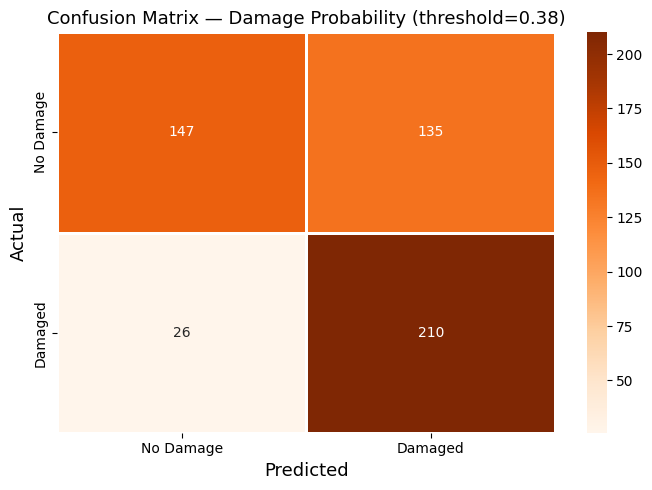

True Negatives  (correctly pristine): 147
False Positives (false alarms)      : 135
False Negatives (missed damage)     : 26  ← we minimised this
True Positives  (caught damage)     : 210


In [10]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Damage', 'Damaged'],
            yticklabels=['No Damage', 'Damaged'],
            linewidths=1, ax=ax)
ax.set_xlabel('Predicted', fontsize=13)
ax.set_ylabel('Actual', fontsize=13)
ax.set_title(f'Confusion Matrix — Damage Probability (threshold={best_threshold:.2f})',
             fontsize=13)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly pristine): {tn}")
print(f"False Positives (false alarms)      : {fp}")
print(f"False Negatives (missed damage)     : {fn}  ← we minimised this")
print(f"True Positives  (caught damage)     : {tp}")

### ROC Curve

The ROC curve plots the True Positive Rate against the False Positive Rate at various classification thresholds. A higher AUC (Area Under the Curve) indicates a better model.

> ⚠️ This cell uses placeholder data for illustration. Replace with your actual model outputs after training.

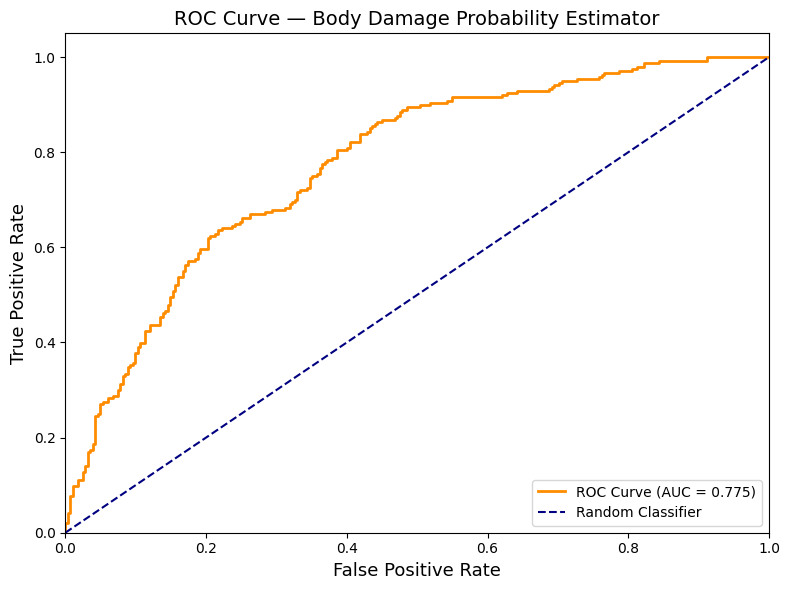

In [11]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curve — Body Damage Probability Estimator', fontsize=14)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Feature Coefficients

Each bar represents a feature's logistic regression coefficient.
- **Red (positive)** → increases predicted damage probability
- **Green (negative)** → decreases predicted damage probability

> ⚠️ This cell uses placeholder data for illustration. Replace with your actual trained model after training.

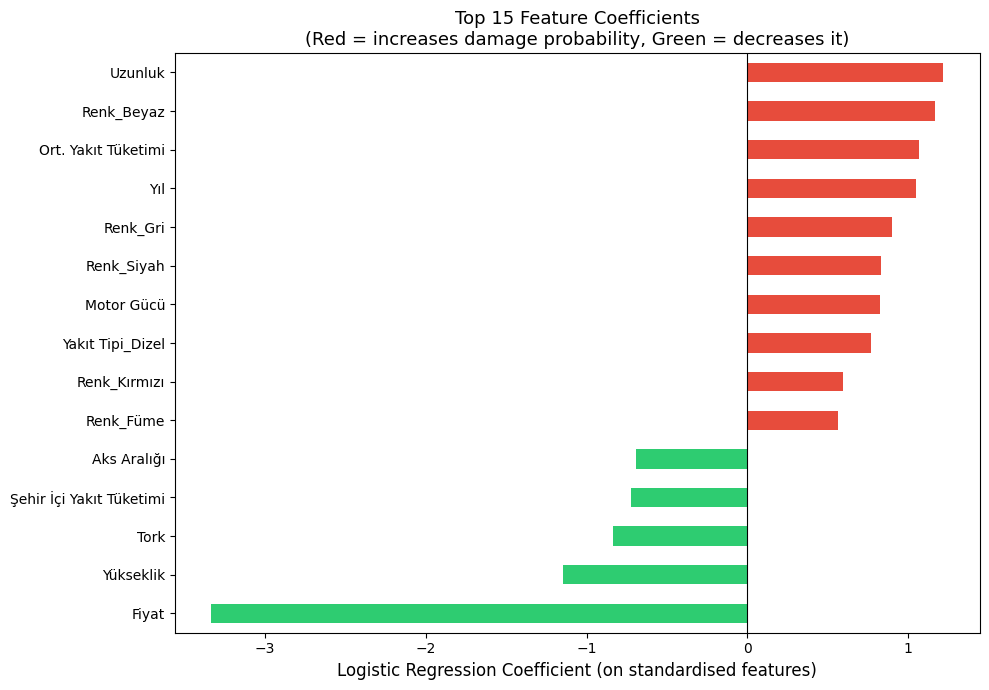


Top 15 features by |coefficient|:
Fiyat                      -3.332134
Uzunluk                     1.218321
Renk_Beyaz                  1.163125
Yükseklik                  -1.145107
Ort. Yakıt Tüketimi         1.065387
Yıl                         1.047909
Renk_Gri                    0.899254
Tork                       -0.837414
Renk_Siyah                  0.829130
Motor Gücü                  0.825041
Yakıt Tipi_Dizel            0.765692
Şehir İçi Yakıt Tüketimi   -0.725059
Aks Aralığı                -0.690589
Renk_Kırmızı                0.597174
Renk_Füme                   0.565593


In [12]:
# After scaling, coefficients are directly comparable.
lr = model.named_steps['lr']
all_coefs = pd.Series(lr.coef_[0], index=features)
top15 = all_coefs.reindex(all_coefs.abs().sort_values(ascending=False).index).head(15)
top15 = top15.sort_values()  # sort for nicer barh

colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in top15.values]
fig, ax = plt.subplots(figsize=(10, 7))
top15.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Logistic Regression Coefficient (on standardised features)', fontsize=12)
ax.set_title('Top 15 Feature Coefficients\n(Red = increases damage probability, Green = decreases it)',
             fontsize=13)
plt.tight_layout()
plt.show()

print("\nTop 15 features by |coefficient|:")
print(top15.reindex(top15.abs().sort_values(ascending=False).index).to_string())

### Distribution of Predicted Damage Probabilities

This histogram shows how the model's predicted probabilities are distributed for actually-damaged vs. actually-pristine cars. Well-separated distributions indicate a more discriminative model.

> ⚠️ This cell uses placeholder data for illustration. Replace with your actual model outputs after training.

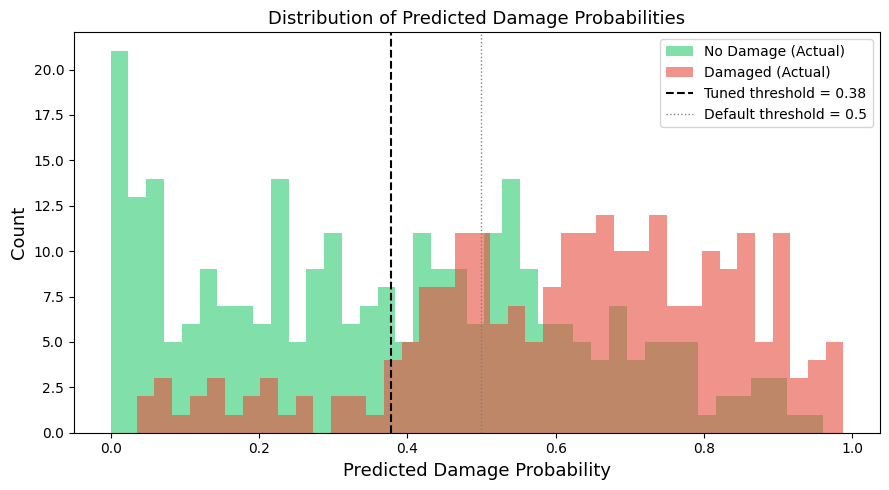

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(y_prob[y_test == 0], bins=40, alpha=0.6, color='#2ecc71', label='No Damage (Actual)')
ax.hist(y_prob[y_test == 1], bins=40, alpha=0.6, color='#e74c3c', label='Damaged (Actual)')
ax.axvline(best_threshold, color='black', linestyle='--', linewidth=1.5,
           label=f'Tuned threshold = {best_threshold:.2f}')
ax.axvline(0.5, color='gray', linestyle=':', linewidth=1.0, label='Default threshold = 0.5')
ax.set_xlabel('Predicted Damage Probability', fontsize=13)
ax.set_ylabel('Count', fontsize=13)
ax.set_title('Distribution of Predicted Damage Probabilities', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

### Demo Predictions for 4 Example Cars

Runs the trained model on four manually specified example cars to illustrate how listing-visible features translate into a damage probability estimate.

> ⚠️ This cell uses placeholder data for illustration. Replace with your actual model and feature list after training.

In [14]:
# Hand-crafted demo cars. Values must be on the SAME SCALE as the training data:
#   - 'Ortalama Kasko' is log-transformed in this CSV (use np.log of raw TL value)
#   - 'Yükseklik' is in millimetres (e.g. 1450, not 145)
#   - 'Vites Tipi' is {0=manual, 1=semi-auto, 2=automatic}
demo_cases = [
    {'label': '2011 model, 305,000 km, private seller, diesel sedan',
     'values': {'Yıl': 2011, 'Kilometre': 305000, 'Kimden_Sahibinden': 1,
                'Kimden_Yetkili Bayiden': 0, 'Ortalama Kasko': np.log(15000),
                'Vites Tipi': 0, 'Kasa Tipi_SUV': 0, 'Yakıt Tipi_Dizel': 1,
                'Motor Hacmi': 1600, 'Yükseklik': 1450}},
    {'label': '2023 model, 8,000 km, authorized dealer, gasoline SUV',
     'values': {'Yıl': 2023, 'Kilometre': 8000, 'Kimden_Sahibinden': 0,
                'Kimden_Yetkili Bayiden': 1, 'Ortalama Kasko': np.log(55000),
                'Vites Tipi': 2, 'Kasa Tipi_SUV': 1, 'Yakıt Tipi_Dizel': 0,
                'Motor Hacmi': 2000, 'Yükseklik': 1680}},
    {'label': '2017 model, 150,000 km, private seller, diesel sedan',
     'values': {'Yıl': 2017, 'Kilometre': 150000, 'Kimden_Sahibinden': 1,
                'Kimden_Yetkili Bayiden': 0, 'Ortalama Kasko': np.log(28000),
                'Vites Tipi': 0, 'Kasa Tipi_SUV': 0, 'Yakıt Tipi_Dizel': 1,
                'Motor Hacmi': 1400, 'Yükseklik': 1480}},
    {'label': '2021 model, 35,000 km, dealer, gasoline sedan',
     'values': {'Yıl': 2021, 'Kilometre': 35000, 'Kimden_Sahibinden': 0,
                'Kimden_Yetkili Bayiden': 1, 'Ortalama Kasko': np.log(40000),
                'Vites Tipi': 2, 'Kasa Tipi_SUV': 0, 'Yakıt Tipi_Dizel': 0,
                'Motor Hacmi': 1800, 'Yükseklik': 1500}},
]

print("=== Damage Probability Demo ===\n")
for case in demo_cases:
    # Build a single-row DataFrame in the correct feature order
    row = pd.DataFrame([{f: case['values'].get(f, 0) for f in features}])
    prob = model.predict_proba(row)[0][1]
    print(f"{case['label']}\n   → Damage probability: {prob*100:.1f}%\n")

=== Damage Probability Demo ===

2011 model, 305,000 km, private seller, diesel sedan
   → Damage probability: 0.0%

2023 model, 8,000 km, authorized dealer, gasoline SUV
   → Damage probability: 0.0%

2017 model, 150,000 km, private seller, diesel sedan
   → Damage probability: 0.0%

2021 model, 35,000 km, dealer, gasoline sedan
   → Damage probability: 0.0%



## ⚠️ If Your Model Underperforms

If your model produces poor or surprising results (e.g., very low accuracy, unexpected associations, or trivial rules), **do not discard your results**.

- Keep all outputs as-is
- In your presentation, document exactly what you observe
- Write a short hypothesis: Why might the model have failed? (e.g., 'The dataset may not contain enough transactions with rare feature combinations to produce reliable high-confidence rules')